In [2]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Union
from pathlib import Path
import glob
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

print(f"Added to path: {current_dir}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt


def plot_histograms_with_stats(
    dfs,
    metric,
    titles=None,
    bins='auto',
    density=False,
    x_range=(0, 1),
    ncols=2,
    figsize_per_row=(12, 5),
    shared_y=True,   # <-- new flag
):
    """
    Plot histograms with stats for a list of DataFrames.

    Parameters
    ----------
    dfs : list of pd.DataFrame
        List of DataFrames to plot.
    metric : str
        Column name to plot.
    titles : list of str, optional
        Titles for each histogram. If None, default titles are used.
    bins : int, sequence, or str
        Histogram bins passed to matplotlib.
    density : bool
        Whether to normalize histogram.
    x_range : tuple, optional
        Shared x-axis range for all histograms. If None, computed from all dfs.
    ncols : int
        Number of histograms per row. Default is 2.
    figsize_per_row : tuple
        Base figure size per row, default (12, 5).
    shared_y : bool
        If True, keep the same y-axis scale across all histograms.
    """

    if not dfs:
        print("No DataFrames provided.")
        return

    for i, df in enumerate(dfs):
        if metric not in df.columns:
            print(f"Incorrect metric name in df index {i}: '{metric}' not found.")
            return

    if titles is None:
        titles = [f"DF {i+1}" for i in range(len(dfs))]
    elif len(titles) != len(dfs):
        print("Length of titles must match length of dfs.")
        return

    values_list = [df[metric].dropna() for df in dfs]

    if all(len(values) == 0 for values in values_list):
        print("All DataFrames have only NaN values for this metric.")
        return

    n_plots = len(dfs)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_row[0], figsize_per_row[1] * nrows),
        squeeze=False
    )

    fig.suptitle(metric, fontsize=14)

    range_min, range_max = x_range

    # ---- compute common y-axis max first ----
    common_y_max = None
    bin_edges_global = None

    if shared_y:
        non_empty_values = [np.asarray(v) for v in values_list if len(v) > 0]

        if len(non_empty_values) > 0:
            ref_values = non_empty_values[0]
            _, bin_edges_global = np.histogram(
                ref_values[ref_values <= range_max],
                bins=bins,
                range=(range_min, range_max)
            )

            bin_width = bin_edges_global[1] - bin_edges_global[0]
            y_max_candidates = []

            for values in non_empty_values:
                in_range = values[values <= range_max]
                overflow = values[values > range_max]

                counts, _ = np.histogram(
                    in_range,
                    bins=bin_edges_global,
                    range=(range_min, range_max)
                )

                if density:
                    hist_heights = counts / (len(values) * bin_width)
                    overflow_height = len(overflow) / (len(values) * bin_width)
                else:
                    hist_heights = counts
                    overflow_height = len(overflow)

                current_max = max(
                    np.max(hist_heights) if len(hist_heights) > 0 else 0,
                    overflow_height
                )
                y_max_candidates.append(current_max)

            common_y_max = max(y_max_candidates) * 1.08 if y_max_candidates else None
    # -----------------------------------------

    def _add_hist_with_stats(ax, values, title):
        values = np.asarray(values)

        in_range = values[values <= range_max]
        overflow = values[values > range_max]

        if shared_y and bin_edges_global is not None:
            bin_edges = bin_edges_global
        else:
            _, bin_edges = np.histogram(
                in_range,
                bins=bins,
                range=(range_min, range_max)
            )

        bin_width = bin_edges[1] - bin_edges[0]

        ax.hist(
            values,
            bins=bin_edges,
            density=density,
            range=x_range,
            color="skyblue",
            edgecolor="black"
        )

        overflow_x = range_max + bin_width / 2
        overflow_count = len(overflow)
        overflow_height = (overflow_count / (len(values) * bin_width)) if density else overflow_count

        ax.bar(
            overflow_x,
            overflow_height,
            width=bin_width * 0.95,
            color='skyblue',
            edgecolor='black',
            linewidth=0.8
        )

        ax.set_xlim(range_min, range_max + bin_width * 1.55)

        if shared_y and common_y_max is not None:
            ax.set_ylim(0, common_y_max)

        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins='auto', steps=[1, 2, 5, 10]))
        fig.canvas.draw()

        auto_ticks = [
            t for t in ax.get_xticks()
            if range_min <= t <= range_max and not np.isclose(t, range_max, atol=bin_width * 0.6)
        ]
        tick_positions = auto_ticks + [overflow_x]
        tick_labels = [f'{t:g}' for t in auto_ticks] + [f'≥{range_max:g}']

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')

        ax.set_title(title)
        ax.set_xlabel("Value")
        ax.set_ylabel("Density" if density else "Frequency")

        median_v = np.median(values)

        ax.text(
            0.02,
            0.98,
            f"Median: {median_v:.4f}",
            transform=ax.transAxes,
            va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
            fontsize=10,
        )

    for idx, (values, title) in enumerate(zip(values_list, titles)):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row][col]

        if len(values) == 0:
            ax.set_title(title)
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_axis_off()
        else:
            _add_hist_with_stats(ax, values, title)

    for idx in range(n_plots, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row][col].set_axis_off()

    plt.tight_layout()
    plt.show()

In [4]:
def _prepare_time_filtered_df(df, start_date=None, end_date=None):
    """Helper: ensure datetime and filter by dates."""
    df = df.copy()

    if not pd.api.types.is_datetime64_any_dtype(df["timestamp_utc"]):
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

    if start_date is not None or end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)

        if start_date is not None:
            df = df[df["timestamp_utc"] >= start_date]
        if end_date is not None:
            df = df[df["timestamp_utc"] <= end_date]

    return df


def plot_water_meter_anomalies(
    df_actuals,
    df_predicted,
    df_red_dots,
    figsize=(14, 6),
    title="Water Meter: Actual vs Predicted Values",
    start_date=None,
    end_date=None,
):
    """
    df_actuals:  columns timestamp_utc, Diff
    df_predicted: columns timestamp_utc, predicted, residual, is_anomaly_predicted, is_anomaly_actual
    df_red_dots: columns timestamp_utc (candidate extra timestamps)
    """

    # --- 3-sigma band based on residuals ---
    if not df_predicted.empty and "residual" in df_predicted.columns:
        res_mean = df_predicted["residual"].mean()
        res_std = df_predicted["residual"].std(ddof=1)
        band = res_mean + 3 * res_std

        df_predicted = df_predicted.copy()
        df_predicted["upper_band"] = df_predicted["predicted"] + band
        df_predicted["lower_band"] = df_predicted["predicted"] - band
    # ---------------------------------------
    
    # Prepare and filter separately
    df_a = _prepare_time_filtered_df(df_actuals, start_date, end_date)
    df_p = _prepare_time_filtered_df(df_predicted, start_date, end_date)
    df_r = _prepare_time_filtered_df(df_red_dots, start_date, end_date)
    df_r_line = pd.DataFrame()

    # Keep only timestamps where Diff is NaN in df_a but not NaN in df_r
    if not df_a.empty and not df_r.empty:
        # Select only needed columns to avoid clashes
        tmp_a = df_a[["timestamp_utc", "Diff"]].rename(columns={"Diff": "Diff_a"})
        tmp_r = df_r[["timestamp_utc", "Diff"]].rename(columns={"Diff": "Diff_r"})
    
        merged = tmp_r.merge(tmp_a, on="timestamp_utc", how="left")
    
        # Condition: Diff_a is NaN (missing in actuals) AND Diff_r is not NaN
        mask = merged["Diff_a"].isna() & merged["Diff_r"].notna()
    
        # Keep only those timestamps in df_r
        df_r = df_r[df_r["timestamp_utc"].isin(merged.loc[mask, "timestamp_utc"])]
        
        df_r_line = df_r[df_r["timestamp_utc"] < df_a["timestamp_utc"].iloc[0]].copy()
        df_r = df_r[df_r["timestamp_utc"] >= df_a["timestamp_utc"].iloc[0]]


    # Update title if zoomed
    if start_date is not None and end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)
        date_range = (
            f" ({start_date.strftime('%Y-%m-%d %H:%M')} "
            f"to {end_date.strftime('%Y-%m-%d %H:%M')})"
        )
        title = title + date_range

    fig, ax = plt.subplots(figsize=figsize, dpi=100)

    # Actuals (Diff)
    ax.plot(
        df_a["timestamp_utc"],
        df_a["Diff"],
        color="#2E86AB",
        linewidth=2.5,
        marker="o",
        markersize=5,
        label="Actual (Diff)",
        zorder=3,
        alpha=0.9,
    )

    # Predicted
    ax.plot(
        df_p["timestamp_utc"],
        df_p["predicted"],
        color="#A23B72",
        linewidth=2,
        marker="s",
        markersize=4,
        label="Predicted",
        zorder=2,
        alpha=0.8,
        linestyle="--",
    )
    
    # 3-sigma upper/lower band
    if "upper_band" in df_p.columns and "lower_band" in df_p.columns:
        ax.plot(
            df_p["timestamp_utc"],
            df_p["upper_band"],
            color="gray",
            linestyle=":",
            linewidth=1.5,
            label="3σ upper band",
            zorder=1,
            alpha=0.8,
        )
        ax.plot(
            df_p["timestamp_utc"],
            df_p["lower_band"],
            color="gray",
            linestyle=":",
            linewidth=1.5,
            label="3σ lower band",
            zorder=1,
            alpha=0.8,
        )
        # Optional: shaded band
        #ax.fill_between(
        #    df_p["timestamp_utc"],
        #    df_p["lower_band"],
        #    df_p["upper_band"],
        #    color="gray",
        #    alpha=0.15,
        #    zorder=0,
        #)

    # Red dots only for timestamps not in df_actuals
    if not df_r.empty:
        ax.scatter(
            df_r["timestamp_utc"],
            df_r["Diff"],  # or np.nan if you want them detached from y-scale
            color="red",
            s=40,
            marker="o",
            label="Extra timestamps",
            zorder=5,
        )
    
    if not df_r_line.empty:    
        ax.plot(
            df_r_line["timestamp_utc"],
            df_r_line["Diff"],
            color="red",
            linewidth=2.5,
            marker="o",
            markersize=5,
            label="Training Data",
            zorder=3,
            alpha=0.8,
        )

    # Optional anomalies on actuals
    if "is_anomaly_predicted" in df_p.columns:
        anomalies = df_p[df_p["is_anomaly_predicted"] == 1]
        if len(anomalies) > 0:
            ax.scatter(
                anomalies["timestamp_utc"],
                anomalies["actual"],
                color="#F18F01",
                s=150,
                marker="X",
                label="Anomaly (Predicted)",
                zorder=4,
                edgecolors="#C41E3A",
                linewidth=2,
            )
            
    # Optional anomalies on actuals
    if "is_anomaly_actual" in df_p.columns:
        anomalies = df_p[df_p["is_anomaly_actual"] != 0]
        if len(anomalies) > 0:
            ax.scatter(
                anomalies["timestamp_utc"],
                anomalies["actual"],
                color="#FF03CD",
                s=150,
                marker="P",
                label="Anomaly (Actual)",
                zorder=4,
                edgecolors="#C41E3A",
                linewidth=2,
            )

    ax.set_xlabel("Timestamp (UTC)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Water Consumption (Diff)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)

    # Determine global time range from all non-empty dfs
    timestamps = []
    for d in (df_a, df_p, df_r):
        if not d.empty:
            timestamps.append(d["timestamp_utc"].min())
            timestamps.append(d["timestamp_utc"].max())

    if timestamps:
        t_min, t_max = min(timestamps), max(timestamps)
        time_range = (t_max - t_min).total_seconds()
    else:
        time_range = 0

    if time_range < 3600:
        date_format = "%H:%M:%S"
        date_locator = mdates.MinuteLocator(interval=10)
    elif time_range < 86400:
        date_format = "%H:%M"
        date_locator = mdates.HourLocator(interval=2)
    elif time_range < 604800:
        date_format = "%Y-%m-%d %H:%M"
        date_locator = mdates.AutoDateLocator()
    else:
        date_format = "%Y-%m-%d"
        date_locator = mdates.AutoDateLocator()

    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(date_locator)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc="best", fontsize=10, framealpha=0.95)
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("white")
    fig.tight_layout()

    return fig, ax


In [5]:
from pathlib import Path
from typing import List
import numpy as np
import pandas as pd
import pickle

# Extra columns for timing information
EXTRA_COLS = [
    "train_train_time_seconds",
    "second_train_time_seconds",
    "prediction_time_seconds",
    "number_of_anomalies",
    "number_of_anomalies_robust",
]

def load_model_results(csv_filepath: str, verbose: bool = True) -> pd.DataFrame:
    """
    Load and filter model results from CSV file.

    Returns only successful runs.
    """
    try:
        df = pd.read_csv(csv_filepath)
        successful = df[df["status"] == "success"].copy()

        if verbose and len(successful) > 0:
            print(f"✓ Loaded {len(successful)} successful runs from {csv_filepath}")

        return successful
    except Exception as e:
        print(f"✗ Error loading {csv_filepath}: {e}")
        return pd.DataFrame()

def extract_metrics(
    df: pd.DataFrame,
    include_non_zero_only: bool = False,
    unresampled: bool = False,
) -> pd.DataFrame:
    """
    Extract metric columns from results dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Results dataframe
    include_non_zero_only : bool
        If True, extract only _nz metrics and summary count metrics
    unresampled : bool
        If True, use unresampled_metric_* columns, otherwise metric_* columns
    """
    if unresampled:
        metric_cols = [col for col in df.columns if col.startswith("unresampled_metric_")]
        total_count_col = "unresampled_metric_total_count"
        non_zero_count_col = "unresampled_metric_non_zero_count"
        zero_count_col = "unresampled_metric_zero_count"
        non_zero_percentage_col = "unresampled_metric_non_zero_percentage"
    else:
        metric_cols = [col for col in df.columns if col.startswith("metric_")]
        total_count_col = "metric_total_count"
        non_zero_count_col = "metric_non_zero_count"
        zero_count_col = "metric_zero_count"
        non_zero_percentage_col = "metric_non_zero_percentage"

    if include_non_zero_only:
        metric_cols = [
            col
            for col in metric_cols
            if col.endswith("_nz")
            or col in [
                total_count_col,
                non_zero_count_col,
                zero_count_col,
                non_zero_percentage_col,
            ]
        ]

    return df[metric_cols]

def compute_metrics_summary(
    csv_filepaths: List[str],
    model_names: List[str] = None,
    include_non_zero_only: bool = False,
    only_converged: bool = True,
    verbose: bool = True,
    unresampled: bool = False,
    exclude_high_mae: bool = False,   # <-- new flag
    mae_threshold: float = 50.0,      # <-- optional parameter
) -> pd.DataFrame:
    """
    Compute mean, std and median of metrics across samples for each model.

    Important:
    Only considers filenames that are successful and converged in all models.
    Metric type is controlled by the unresampled flag.
    Optionally excludes files where (un)resampled_metric_mae > mae_threshold.
    """
    if not csv_filepaths:
        raise ValueError("No CSV files found")

    if model_names is None:
        model_names = [Path(f).stem for f in csv_filepaths]

    if len(csv_filepaths) != len(model_names):
        raise ValueError(
            f"Mismatch: {len(csv_filepaths)} files vs {len(model_names)} names"
        )

    model_data_metrics = {}
    model_data_full = {}
    all_metrics = set()
    successful_counts = {}
    per_model_filenames = {}
    per_model_filenames_all = {}

    if verbose:
        print(f"Loading {len(csv_filepaths)} model(s)...")
        print("-" * 80)

    # choose which MAE column to use
    mae_col = "unresampled_metric_mae" if unresampled else "metric_mae"

    for filepath, model_name in zip(csv_filepaths, model_names):
        df = load_model_results(filepath, verbose=verbose)
        
        per_model_filenames_all[model_name] = set(df["filename"].dropna().unique())

        if only_converged:
            if "converged_train" not in df.columns or "converged_second" not in df.columns:
                raise ValueError(
                    f"Columns 'converged_train' and/or 'converged_second' not found in {filepath}"
                )
            df = df[
                (df["converged_train"] == True) &
                (df["converged_second"] == True)
            ].copy()

            if verbose:
                print(f"  {model_name}: filtered to {len(df)} converged runs")

        if "filename" not in df.columns:
            raise ValueError(f"'filename' column not found in {filepath}")

        # ---- NEW FILTER HERE ----
        if exclude_high_mae:
            if mae_col not in df.columns:
                raise ValueError(f"Column '{mae_col}' not found in {filepath}")
            before = len(df)
            df = df[df[mae_col] <= mae_threshold].copy()
            if verbose:
                removed = before - len(df)
                print(
                    f"  {model_name}: excluded {removed} rows with {mae_col} > {mae_threshold}"
                )
        # -------------------------

        per_model_filenames[model_name] = set(df["filename"].dropna().unique())
        model_data_full[model_name] = df

    if not per_model_filenames:
        raise ValueError("No models loaded")

    common_filenames = set.intersection(*per_model_filenames.values())
    
    #with open('./pickles/common_filenames.pkl', 'wb') as f:
    #    pickle.dump(common_filenames, f)
    
    common_filenames_all = set.intersection(*per_model_filenames_all.values())
    
    with open('./pickles/common_filenames_all.pkl', 'wb') as f:
        pickle.dump(common_filenames_all, f)

    if verbose:
        print("-" * 80)
        print(
            f"Common filenames across all models (successful + converged"
            f"{' + MAE filtered' if exclude_high_mae else ''}): {len(common_filenames)}"
        )

    # --- rest of your original function stays the same ---
    for model_name in model_names:
        df = model_data_full[model_name]
        df = df[df["filename"].isin(common_filenames)].copy()

        if len(df) > 0:
            metrics_df = extract_metrics(
                df,
                include_non_zero_only=include_non_zero_only,
                unresampled=unresampled,
            )
            model_data_metrics[model_name] = metrics_df
            model_data_full[model_name] = df
            successful_counts[model_name] = len(metrics_df)
            all_metrics.update(metrics_df.columns)

            if verbose:
                print(f"  {model_name}: {len(metrics_df)} rows after filename intersection")
        else:
            model_data_metrics[model_name] = None
            model_data_full[model_name] = None
            successful_counts[model_name] = 0

            if verbose:
                print(f"  {model_name}: 0 rows after filename intersection")

    if verbose:
        print("-" * 80)

    all_metrics = sorted(all_metrics)
    summary_rows = []

    for metric in all_metrics:
        row_data = {"Metric": metric}

        for model_name in model_names:
            if model_data_metrics[model_name] is None:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
                row_data[f"{model_name}_Median"] = np.nan
            else:
                metrics_df = model_data_metrics[model_name]
                if metric in metrics_df.columns:
                    series = metrics_df[metric]
                    row_data[f"{model_name}_Mean"] = series.mean()
                    row_data[f"{model_name}_Std"] = series.std()
                    row_data[f"{model_name}_Median"] = series.median()
                else:
                    row_data[f"{model_name}_Mean"] = np.nan
                    row_data[f"{model_name}_Std"] = np.nan
                    row_data[f"{model_name}_Median"] = np.nan

        summary_rows.append(row_data)

    for time_col in EXTRA_COLS:
        row_data = {"Metric": time_col}

        for model_name in model_names:
            df_full = model_data_full.get(model_name)
            if df_full is None or time_col not in df_full.columns:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
                row_data[f"{model_name}_Median"] = np.nan
            else:
                series = df_full[time_col]
                row_data[f"{model_name}_Mean"] = series.mean()
                row_data[f"{model_name}_Std"] = series.std()
                row_data[f"{model_name}_Median"] = series.median()

        summary_rows.append(row_data)

    summary_df = pd.DataFrame(summary_rows)

    summary_df.attrs["model_names"] = model_names
    summary_df.attrs["successful_counts"] = successful_counts
    summary_df.attrs["include_non_zero_only"] = include_non_zero_only
    summary_df.attrs["only_converged"] = only_converged
    summary_df.attrs["unresampled"] = unresampled
    summary_df.attrs["common_filenames_count"] = len(common_filenames)

    return summary_df

def format_metrics_table(
    summary_df: pd.DataFrame,
    model_names: List[str] = None,
    decimal_places: int = 4,
    include_non_zero_only: bool = False,
) -> pd.DataFrame:
    """
    Format metrics summary table as 'mean ± std | median' for display.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "")
                        .replace("_Std", "")
                        .replace("_Median", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    df_display = summary_df.copy()

    if include_non_zero_only:
        df_display = df_display[
            df_display["Metric"].str.contains(
                "_nz|total_count|non_zero_count|non_zero_percentage", na=False
            )
            | df_display["Metric"].isin(EXTRA_COLS)
        ].copy()

    formatted_rows = []

    for _, row in df_display.iterrows():
        formatted_row = {"Metric": row["Metric"]}

        for model_name in model_names:
            mean_col = f"{model_name}_Mean"
            std_col = f"{model_name}_Std"
            median_col = f"{model_name}_Median"

            mean_val = row.get(mean_col, np.nan)
            std_val = row.get(std_col, np.nan)
            median_val = row.get(median_col, np.nan)

            if pd.notna(mean_val) and pd.notna(std_val) and pd.notna(median_val):
                formatted_row[model_name] = (
                    f"{mean_val:.{decimal_places}f} ± "
                    f"{std_val:.{decimal_places}f} | "
                    f"{median_val:.{decimal_places}f}"
                )
            else:
                formatted_row[model_name] = "N/A"

        formatted_rows.append(formatted_row)

    return pd.DataFrame(formatted_rows)

def display_metrics(
    summary_df: pd.DataFrame,
    model_names: List[str] = None,
    show_all: bool = False,
    decimal_places: int = 4,
) -> pd.DataFrame:
    """
    Display metrics summary as a nice pandas table in Jupyter.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "").replace("_Std", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    formatted = format_metrics_table(
        summary_df,
        model_names,
        decimal_places,
        include_non_zero_only=not show_all,
    )

    metric_mode = "unresampled" if summary_df.attrs.get("unresampled", False) else "regular"

    print(f"Metrics Summary - {'Non-Zero Metrics' if not show_all else 'All Metrics'}")
    print(f"Metric type: {metric_mode}")
    print(f"Models: {', '.join(model_names)}")

    if "common_filenames_count" in summary_df.attrs:
        print(f"Common filenames in all models: {summary_df.attrs['common_filenames_count']}")

    if "successful_counts" in summary_df.attrs:
        counts = summary_df.attrs["successful_counts"]
        for m in model_names:
            print(f"  {m}: {counts[m]} rows after common filename filtering")

    print()

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.max_colwidth", None)

    return formatted

def get_metric_comparison(
    summary_df: pd.DataFrame,
    metric_name: str,
    model_names: List[str] = None,
) -> pd.DataFrame:
    """
    Extract comparison for a specific metric across models.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "").replace("_Std", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    metric_row = summary_df[summary_df["Metric"] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        print("\nAvailable metrics:")
        for i, m in enumerate(sorted(summary_df["Metric"].unique()), 1):
            print(f"  {i:2}. {m}")
        return None

    comparison = [{"Metric": metric_name}]

    for model_name in model_names:
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if pd.notna(mean_val):
            comparison[0][model_name] = f"{mean_val:.6f} ± {std_val:.6f}"
        else:
            comparison[0][model_name] = "N/A"

    return pd.DataFrame(comparison)

def list_available_metrics(summary_df: pd.DataFrame) -> None:
    """
    Display list of available metrics.
    """
    metrics = sorted(summary_df["Metric"].unique())

    print(f"Available metrics ({len(metrics)} total):\n")

    for i, m in enumerate(metrics, 1):
        print(f"  {i:2}. {m}")

## Metrics table comparison

In [6]:
csv_files = ['./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_all.csv',
             './gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_train_all.csv']

model_names = ['Local Level Only', 'Daily Seasonal', "Daily + Weekly Fourier", "Daily Steps + Weekly Fourier", "GRU"]

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names, unresampled=True, only_converged=True, exclude_high_mae=False)
table = display_metrics(summary, show_all=True)
display(table)

Loading 5 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_all.csv
  Local Level Only: filtered to 15227 converged runs
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_all.csv
  Daily Seasonal: filtered to 13607 converged runs
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv
  Daily + Weekly Fourier: filtered to 11531 converged runs
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_all.csv
  Daily Steps + Weekly Fourier: filtered to 12601 converged runs
✓ Loaded 19429 successful r

,Metric,Local Level Only,Daily Seasonal,Daily + Weekly Fourier,Daily Steps + Weekly Fourier,GRU
0,unresampled_metric_direction_accuracy,0.5354 ± 0.1403 | 0.5097,0.5910 ± 0.0920 | 0.5876,0.5910 ± 0.0915 | 0.5933,0.5914 ± 0.0897 | 0.5894,0.4941 ± 0.0930 | 0.4908
1,unresampled_metric_direction_accuracy_nz,0.4796 ± 0.1102 | 0.4783,0.5680 ± 0.0998 | 0.5671,0.5719 ± 0.1077 | 0.5752,0.5690 ± 0.0994 | 0.5686,0.4734 ± 0.0948 | 0.4724
2,unresampled_metric_mae,0.1948 ± 1.3981 | 0.0631,43958.3300 ± 3816083.9724 | 0.0608,5222.6385 ± 453411.1882 | 0.0542,67981.3073 ± 5901808.6354 | 0.0613,3258.6894 ± 282134.9322 | 0.0616
3,unresampled_metric_mae_nz,0.2389 ± 1.6446 | 0.0705,66062.6743 ± 5686360.3642 | 0.0679,6390.0734 ± 550009.9042 | 0.0597,99340.4597 ± 8550763.7706 | 0.0683,3649.4097 ± 314132.3703 | 0.0698
4,unresampled_metric_mape,66998775640921.9766 ± 1197733133760153.5000 | 3372429934452.3862,77370289756861235200.0000 ± 6715461586310071844864.0000 | 2795161234607.3765,11855009287287175168.0000 ± 1029214636761845596160.0000 | 2420944402017.3496,124810318291734478848.0000 ± 10834324197687911514112.0000 | 2918280033793.3408,9271105380856696832.0000 ± 804286325067560386560.0000 | 3338350343497.3325
5,unresampled_metric_mape_nz,1.3992 ± 7.0764 | 0.8012,28047120.2683 ± 2414171130.6053 | 0.7947,2115948.3102 ± 182131283.9938 | 0.6859,31757366.8043 ± 2733532632.0285 | 0.8007,1770561.3241 ± 152422429.2372 | 0.8094
6,unresampled_metric_max_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,32233.9981 ± 2568910.8560 | 0.4325
7,unresampled_metric_max_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,29965.7635 ± 2579457.0304 | 0.4395
8,unresampled_metric_mean_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,3258.6894 ± 282134.9322 | 0.0616
9,unresampled_metric_mean_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,3649.4097 ± 314132.3703 | 0.0698


In [7]:
csv_files = ['./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_all.csv',
             './gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_train_all.csv']

model_names = ['Local Level Only', 'Daily Seasonal', "Daily + Weekly Fourier", "Daily Steps + Weekly Fourier", "GRU"]

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names, unresampled=True, only_converged=False, exclude_high_mae=False)
table = display_metrics(summary, show_all=True)
display(table)

Loading 5 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_all.csv
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_all.csv
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_all.csv
✓ Loaded 19429 successful runs from ./gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_train_all.csv
--------------------------------------------------------------------------------
Common filenames across all models (successful

,Metric,Local Level Only,Daily Seasonal,Daily + Weekly Fourier,Daily Steps + Weekly Fourier,GRU
0,unresampled_metric_direction_accuracy,0.6127 ± 0.1923 | 0.5641,0.6223 ± 0.1347 | 0.5962,0.6215 ± 0.1319 | 0.6012,0.6228 ± 0.1316 | 0.5987,0.5241 ± 0.1121 | 0.5120
1,unresampled_metric_direction_accuracy_nz,0.4664 ± 0.1203 | 0.4615,0.5574 ± 0.1094 | 0.5563,0.5542 ± 0.1155 | 0.5524,0.5581 ± 0.1086 | 0.5571,0.4699 ± 0.1027 | 0.4655
2,unresampled_metric_mae,309454312.7884 ± 43103101892.0584 | 0.0231,241581966.7236 ± 33646907993.7182 | 0.0228,289152603.3577 ± 40274349232.2038 | 0.0215,260036526.2100 ± 36216113024.0010 | 0.0229,4269723146.9238 ± 572517325041.7640 | 0.0229
3,unresampled_metric_mae_nz,1243667973.0766 ± 163621524439.8056 | 0.0365,1169271630.7346 ± 153829931170.4886 | 0.0365,1229394838.5502 ± 161743331887.8671 | 0.0334,1194919232.3372 ± 157202360203.1786 | 0.0365,931508448.1002 ± 122570165257.7288 | 0.0373
4,unresampled_metric_mape,329774185238183259668480.0000 ± 45933384289880284615147520.0000 | 4226732832801.6782,87723271526542875820032.0000 ± 12214343385652814707425280.0000 | 4084717700979.9141,250551028427759042953216.0000 ± 34894821839717497120489472.0000 | 3772536460998.9521,148883815723353403031552.0000 ± 20730734815846164712128512.0000 | 4177323720342.8745,18496826874489255590100992.0000 ± 2576375760263407431785119744.0000 | 3822763978334.3818
5,unresampled_metric_mape_nz,22258965682.9612 ± 2928470993330.1260 | 0.8166,7287564247.8727 ± 957192573941.6385 | 0.8294,13580967702.5641 ± 1786640714155.4604 | 0.7563,9539232221.8392 ± 1253226326909.8354 | 0.8353,758552.3780 ± 99721484.6817 | 0.8965
6,unresampled_metric_max_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,90974363467.9848 ± 9870198343174.4414 | 0.1827
7,unresampled_metric_max_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,74520563190.0319 ± 9805613221460.8848 | 0.2283
8,unresampled_metric_mean_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,4269723146.9238 ± 572517325041.7640 | 0.0229
9,unresampled_metric_mean_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,931508448.1002 ± 122570165257.7288 | 0.0373


In [8]:
with open("./pickles/common_filenames.pkl", "rb") as f:
    common_filenames = pickle.load(f)
    
with open("./pickles/common_filenames_all.pkl", "rb") as f:
    common_filenames_all = pickle.load(f)
    
dfs_total = [pd.read_csv(f) for f in csv_files]

dfs = [df[df["filename"].isin(common_filenames)].copy() for df in dfs_total]
dfs_all = [df[df["filename"].isin(common_filenames_all)].copy() for df in dfs_total]


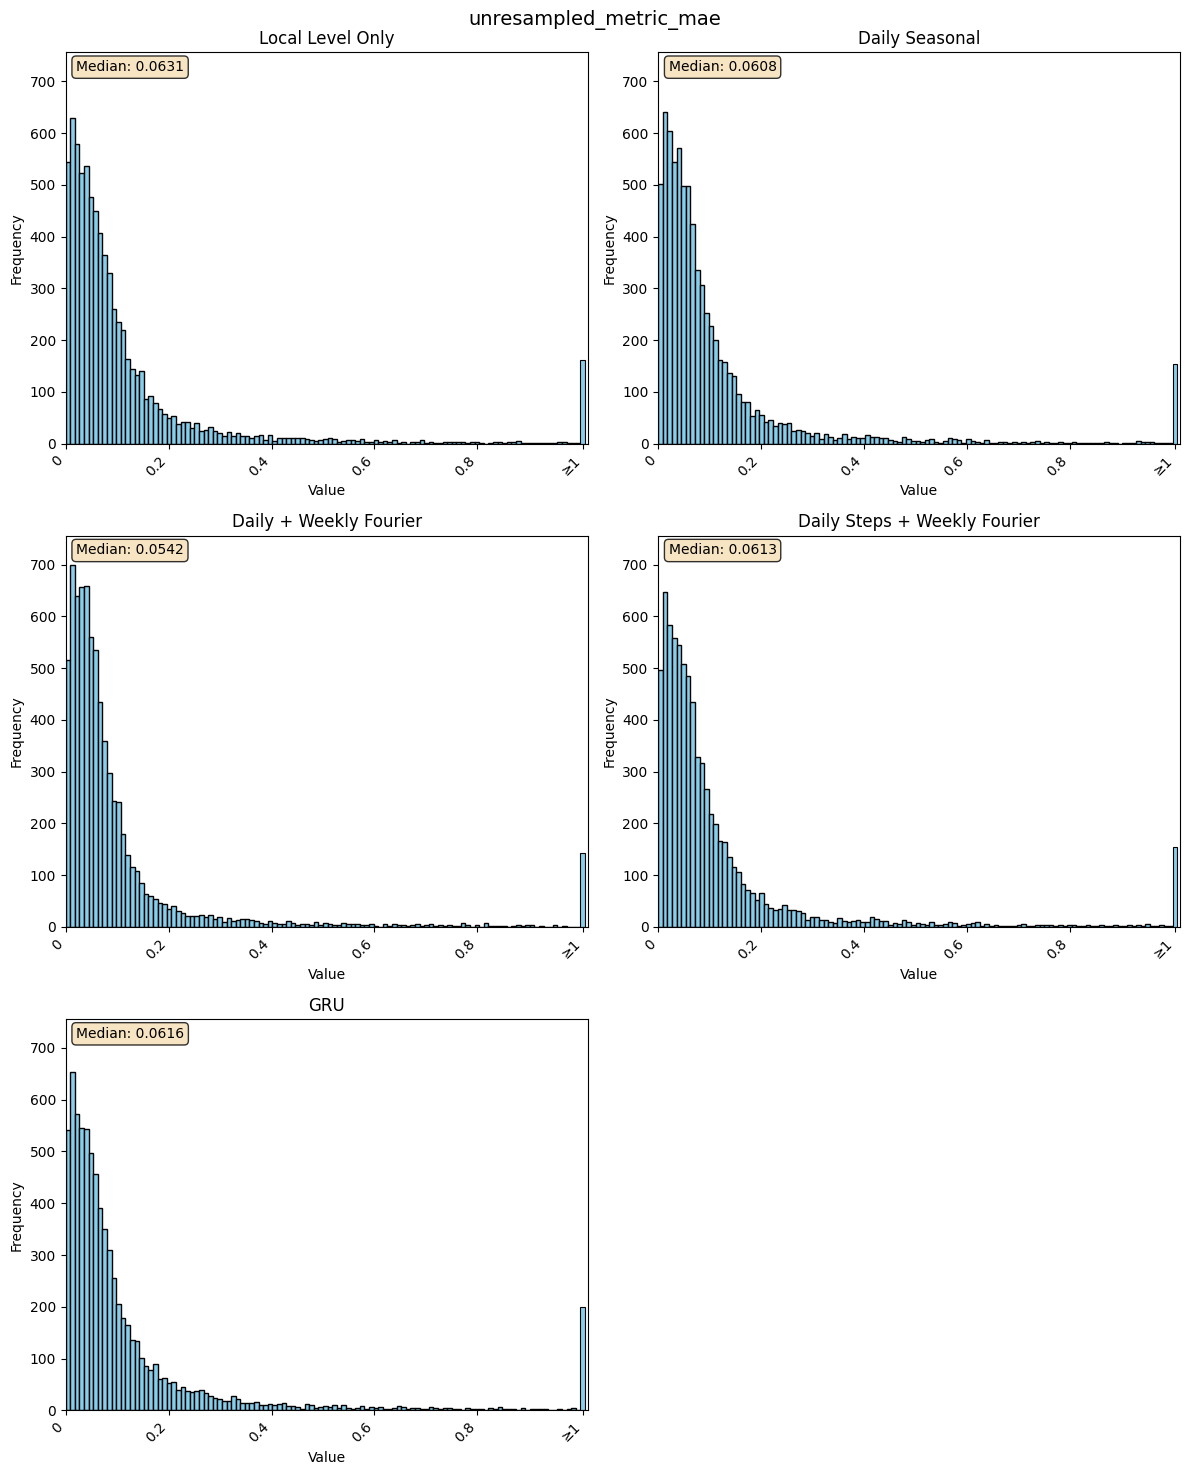

In [9]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_mae",
    titles=model_names,
    x_range=(0, 1)
)

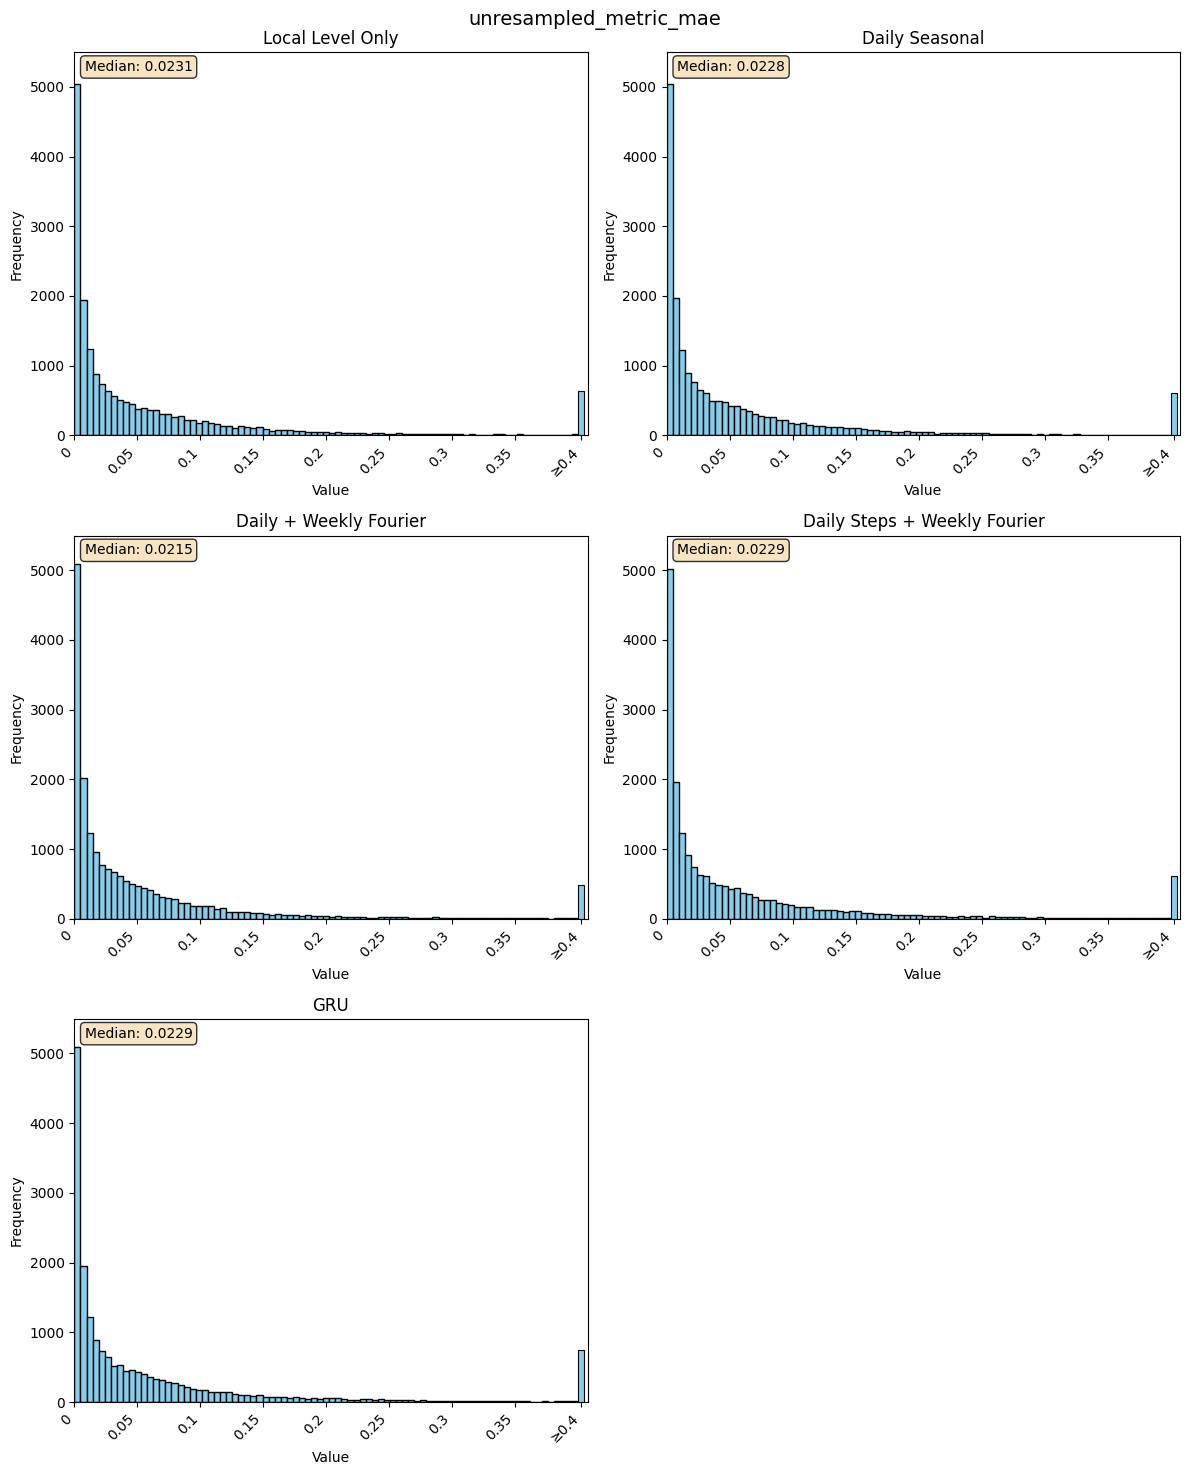

In [10]:
plot_histograms_with_stats(
    dfs=dfs_all,
    metric="unresampled_metric_mae",
    titles=model_names,
    x_range=(0, 0.4)
)

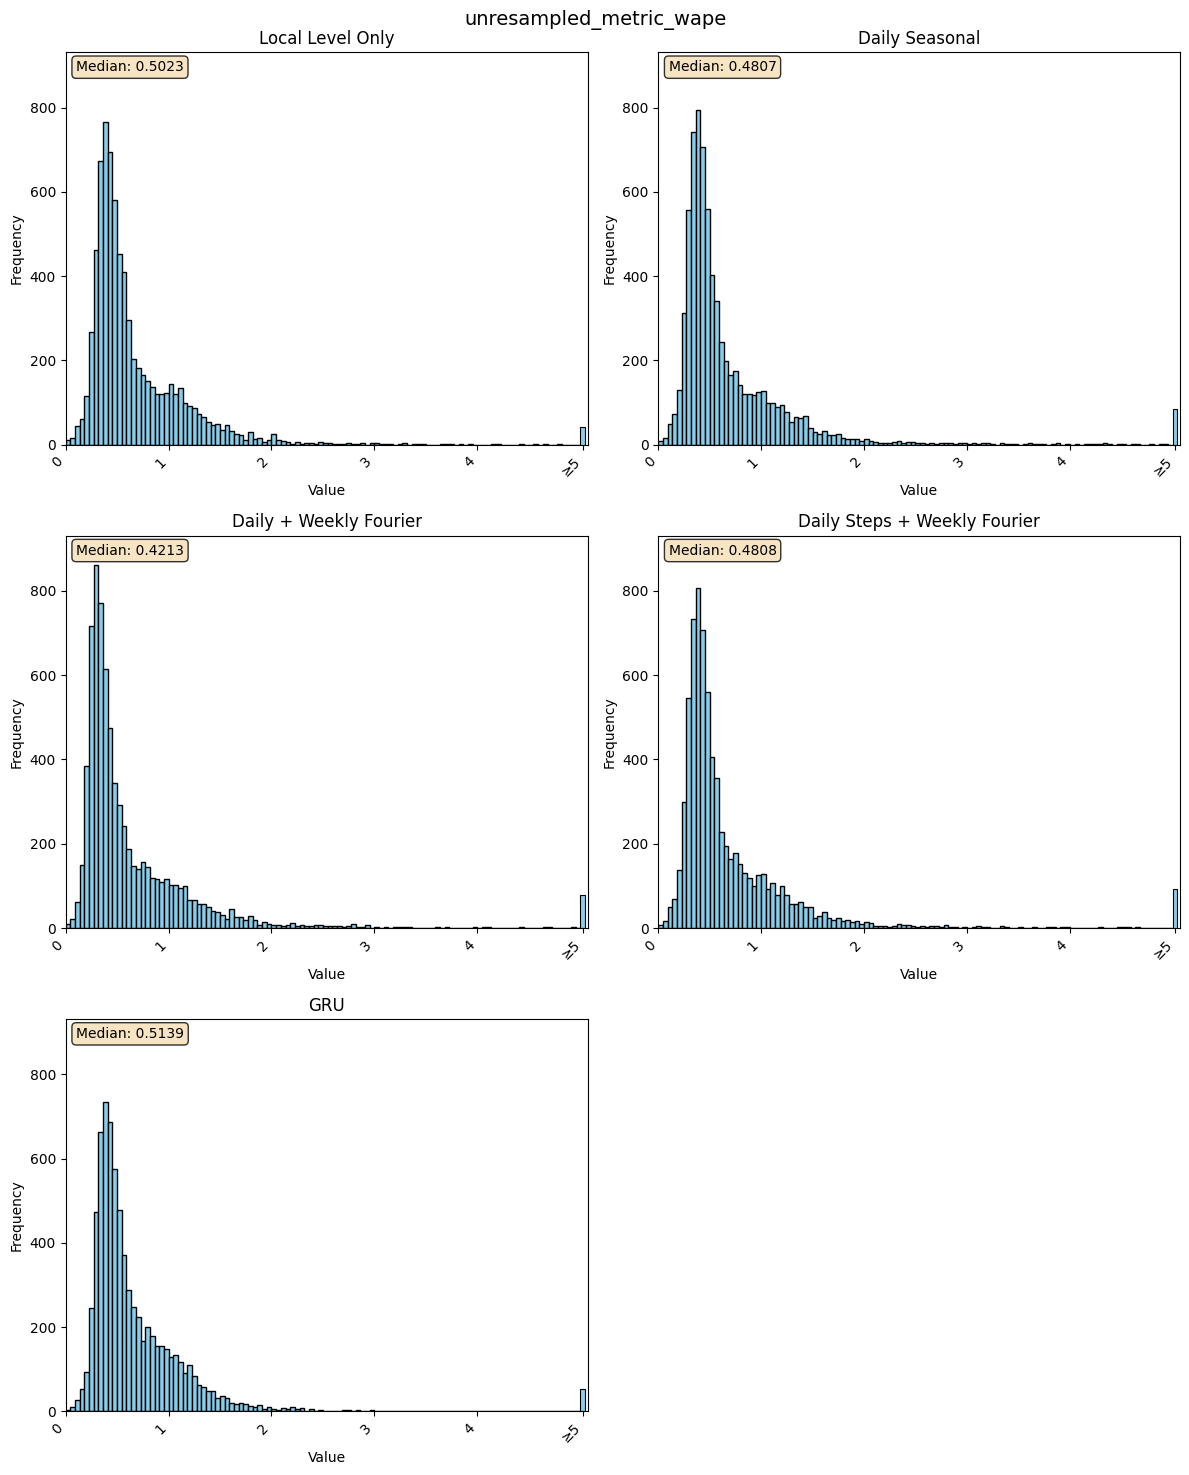

In [11]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_wape",
    titles=model_names,
    x_range=(0, 5)
)

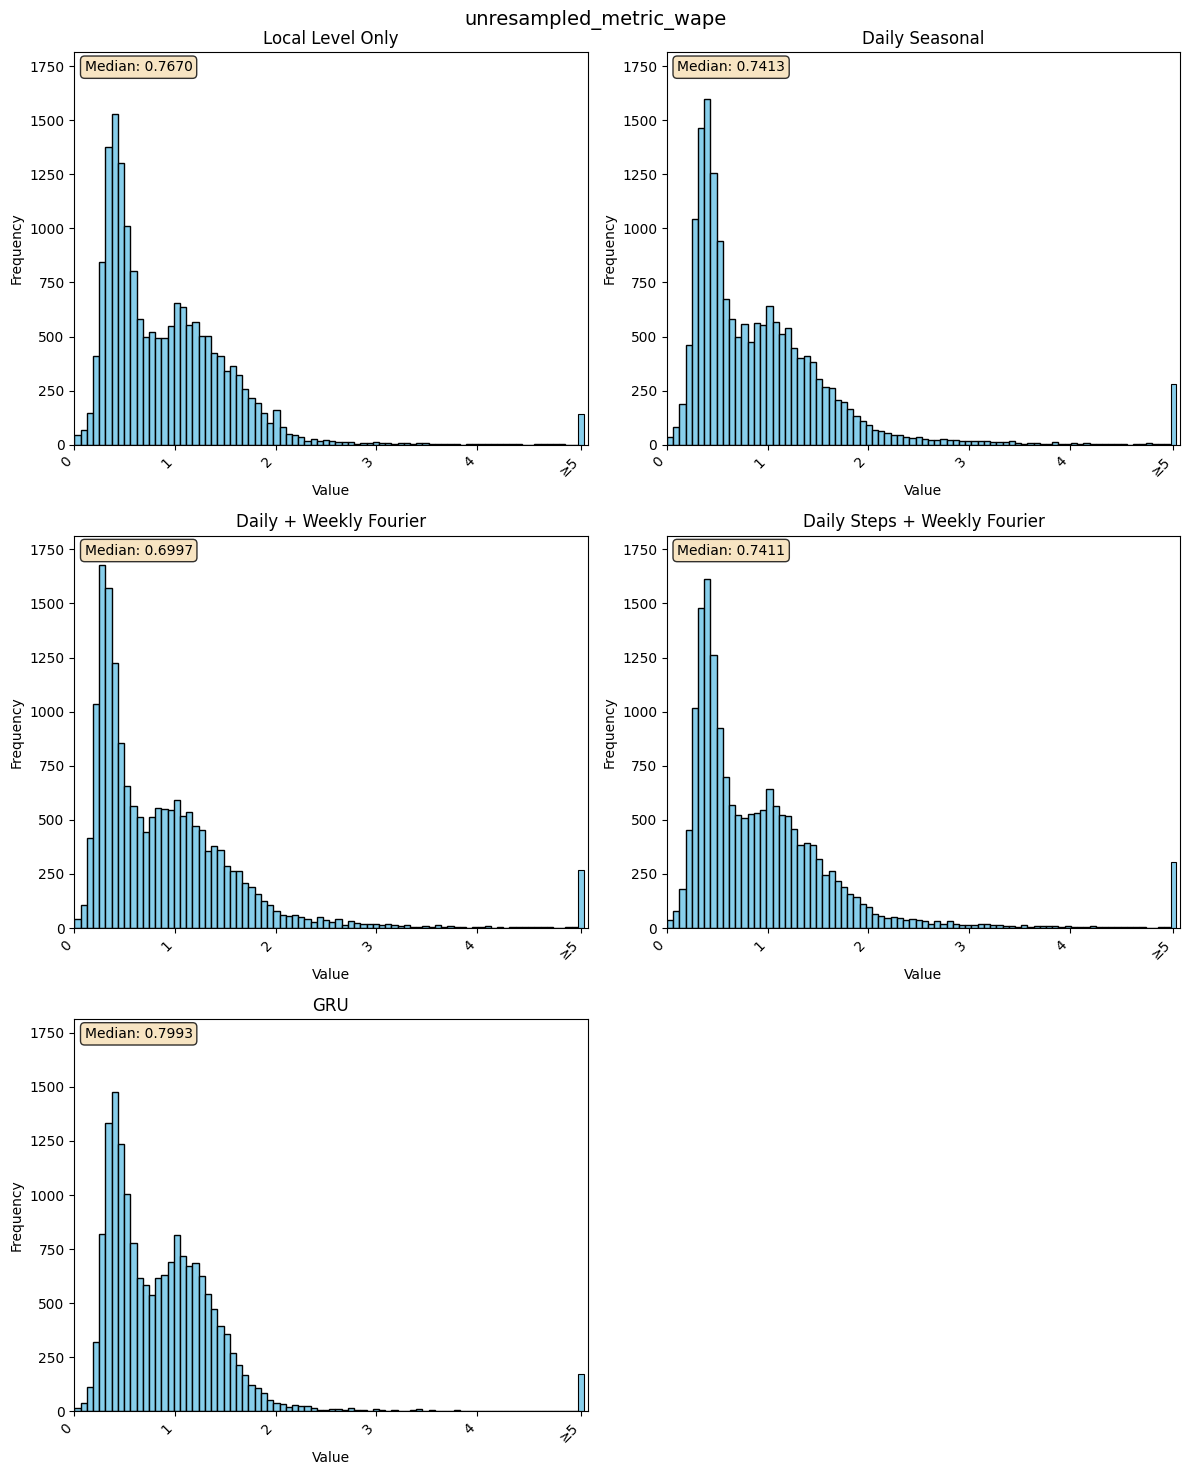

In [12]:
plot_histograms_with_stats(
    dfs=dfs_all,
    metric="unresampled_metric_wape",
    titles=model_names,
    x_range=(0, 5)
)

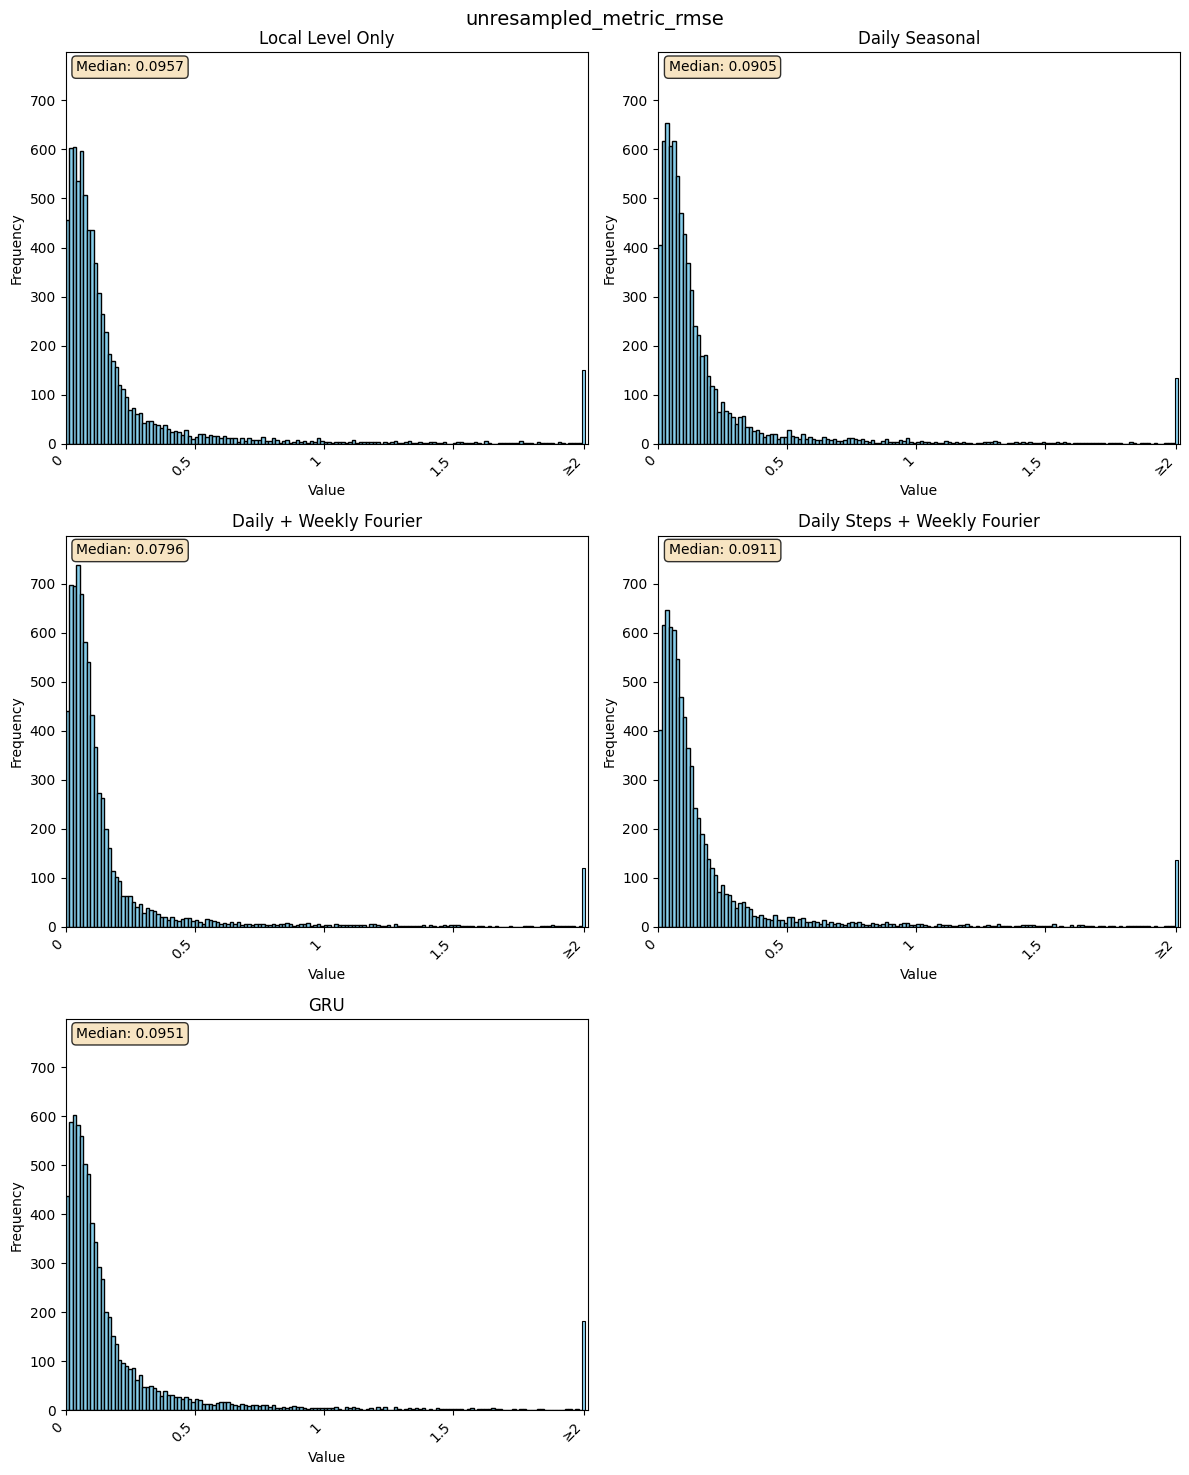

In [13]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_rmse",
    titles=model_names,
    x_range=(0, 2)
)

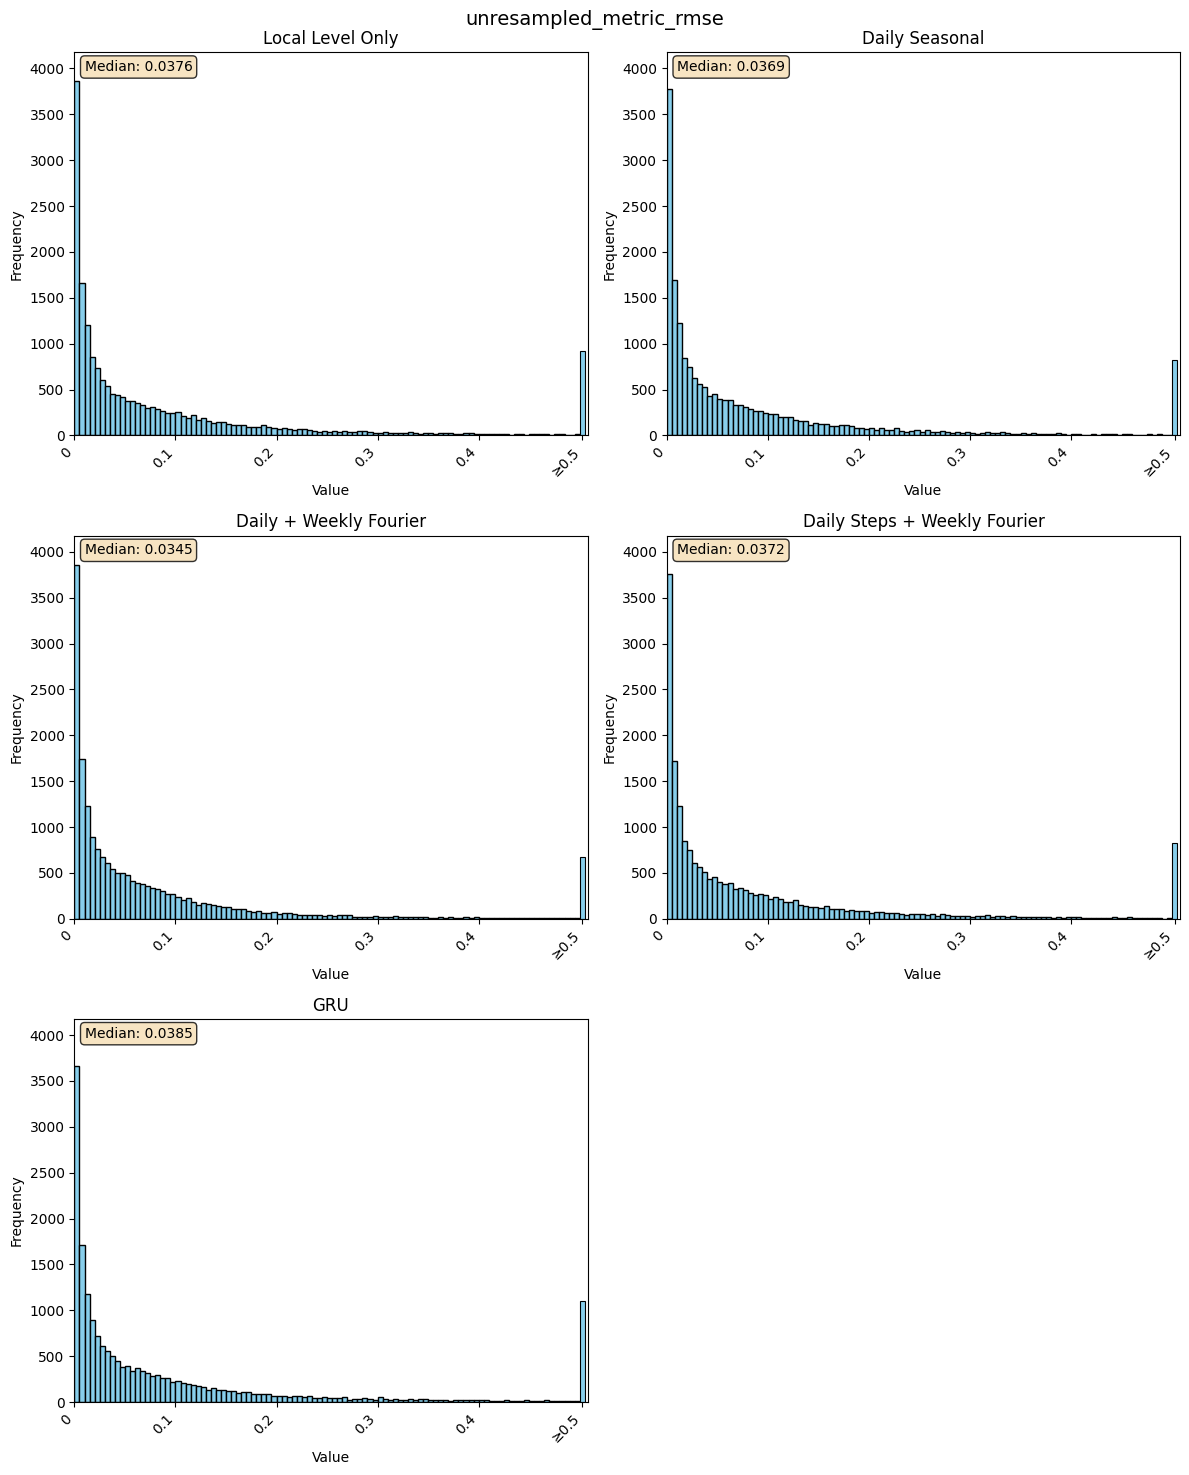

In [14]:
plot_histograms_with_stats(
    dfs=dfs_all,
    metric="unresampled_metric_rmse",
    titles=model_names,
    x_range=(0, 0.5),
    bins=100
)

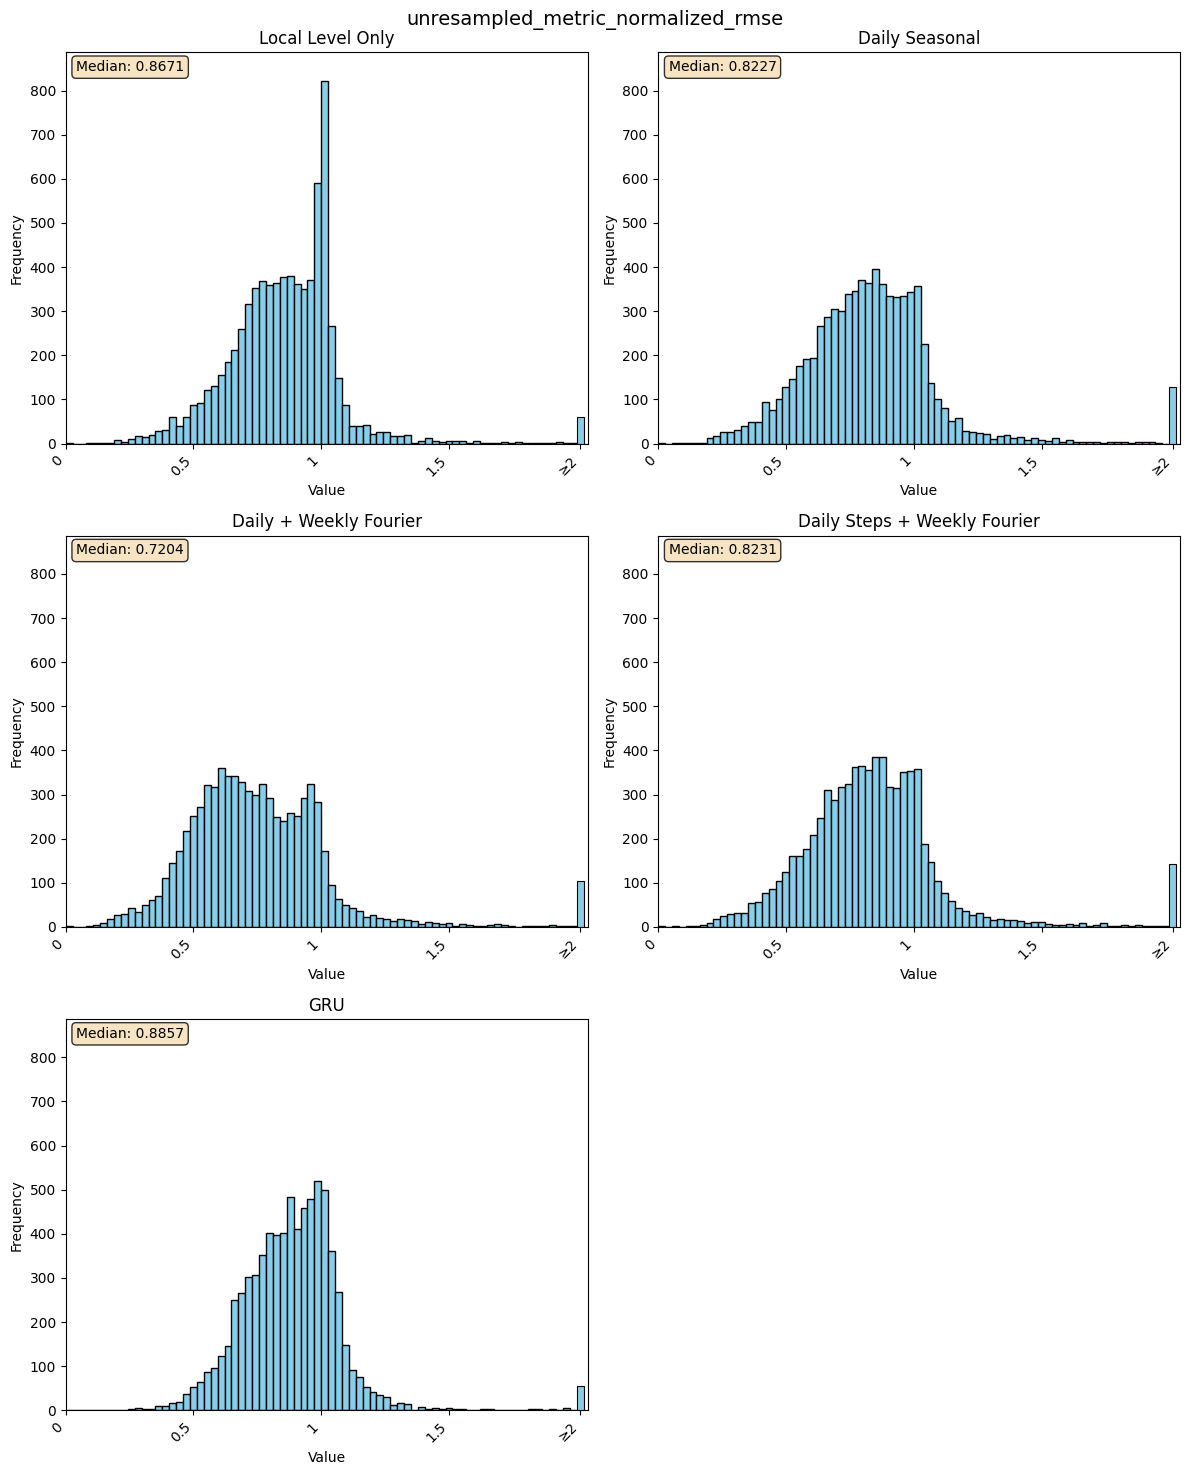

In [15]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_normalized_rmse",
    titles=model_names,
    x_range=(0, 2)
)

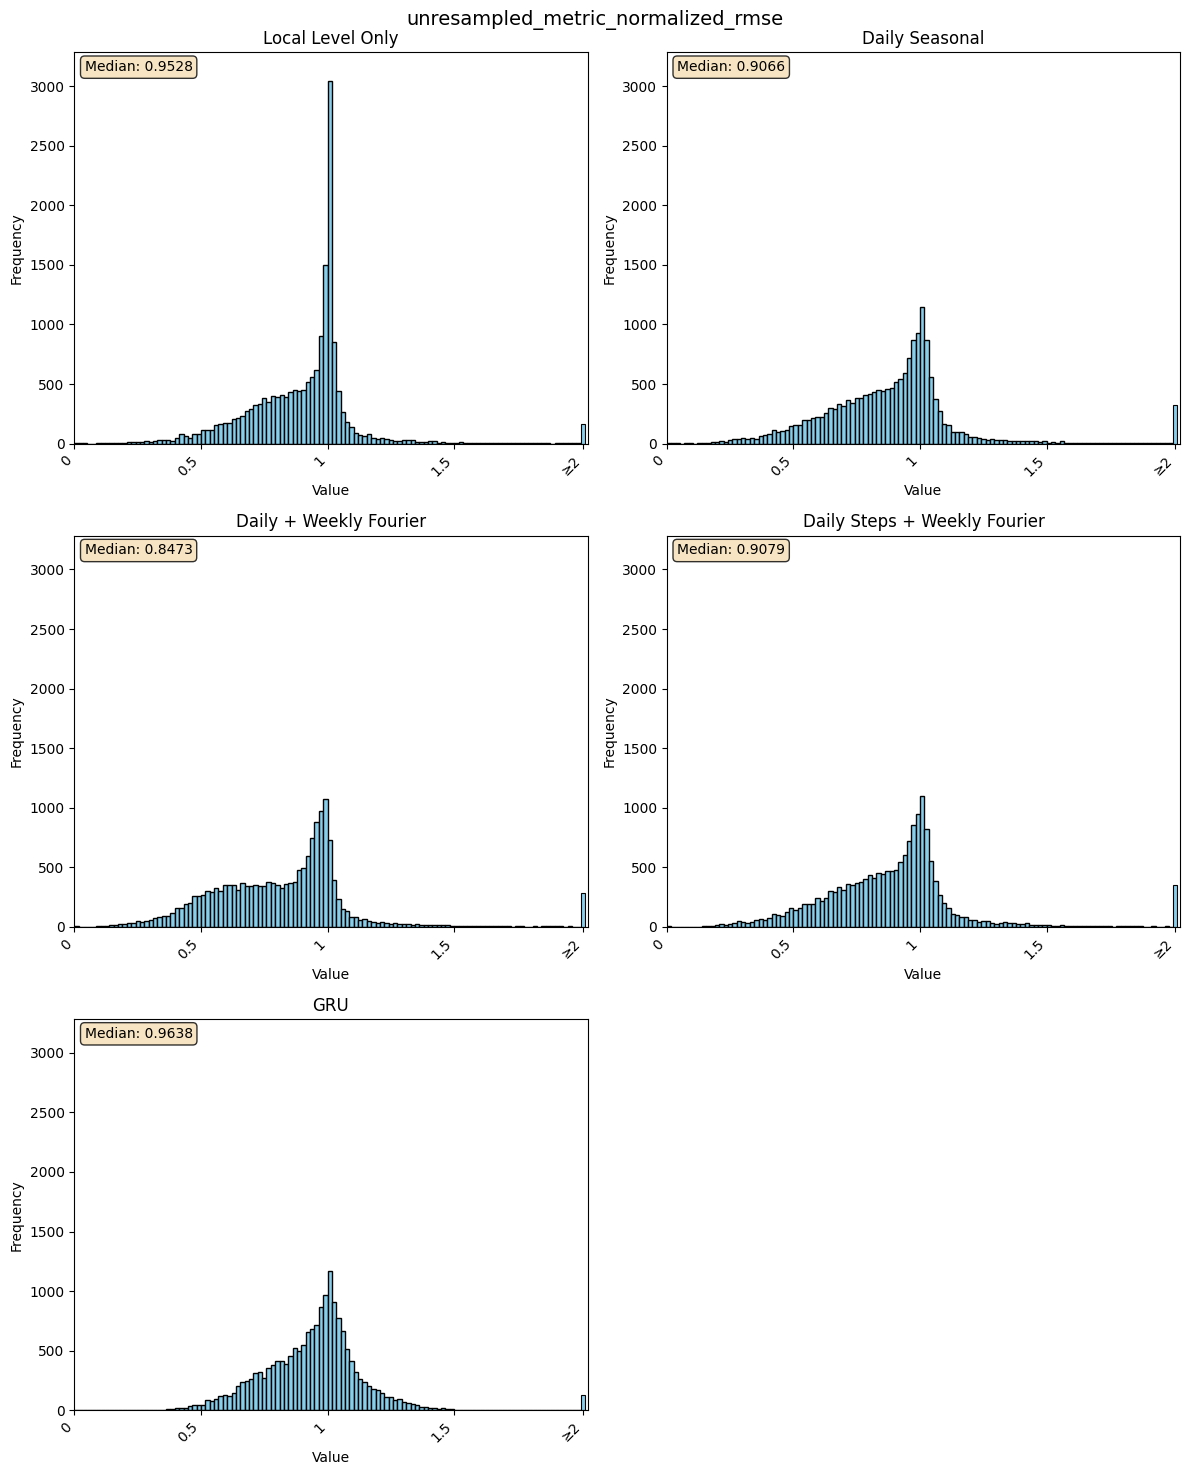

In [16]:
plot_histograms_with_stats(
    dfs=dfs_all,
    metric="unresampled_metric_normalized_rmse",
    titles=model_names,
    x_range=(0, 2)
)

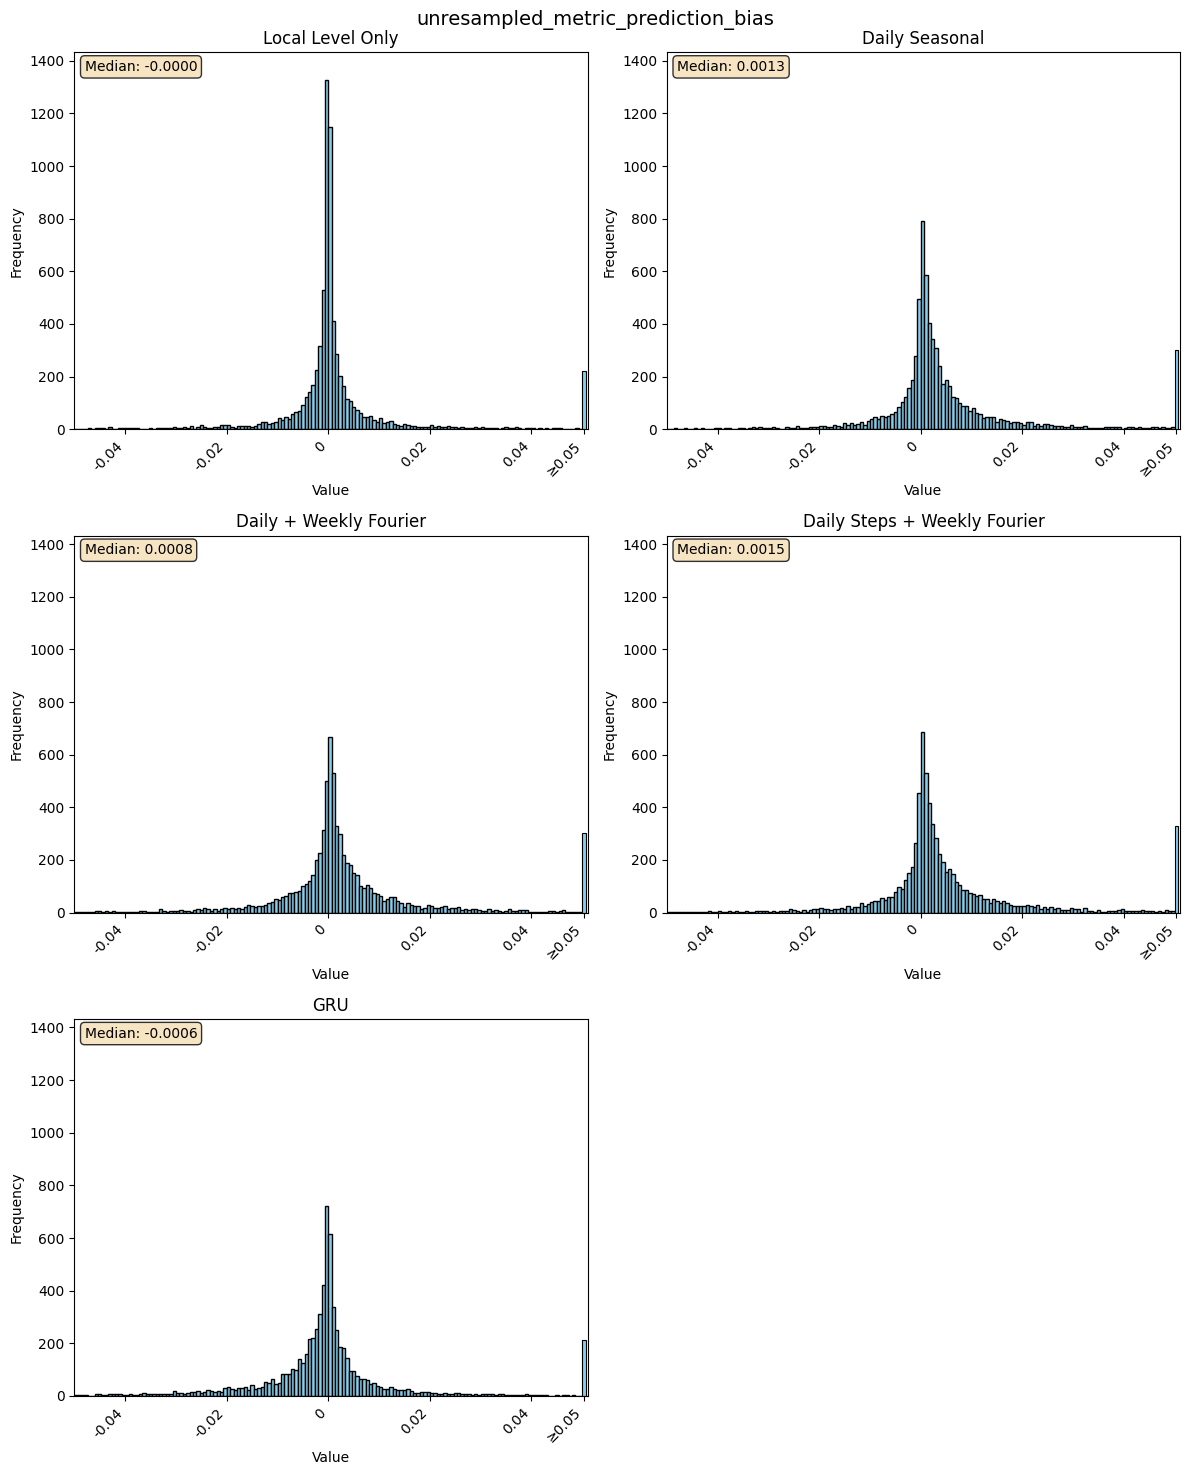

In [17]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_prediction_bias",
    titles=model_names,
    x_range=(-0.05, 0.05),
    bins=150
)

In [18]:
import operator

def get_candidates(df, params):
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        "<": operator.lt,
        ">": operator.gt,
        "<=": operator.le,
        ">=": operator.ge,
    }

    mask = np.ones(len(df), dtype=bool)
    
    for p in params:
        col = p["name"]
        val = p["value"]
        comp = p["comparator"]
        
        if comp not in ops:
            raise ValueError(f"Unsupported comparator: {comp}")
        if col not in df.columns:
            raise ValueError(f"Column {col} not in dataframe")
        
        op = ops[comp]
        mask &= op(df[col], val)
        
    return df[mask]

In [19]:
df_candidates = get_candidates(
    dfs[3],
    params=[
        {"name": "converged_train", "value": True, "comparator": "=="},
        {"name": "converged_second", "value": True, "comparator": "=="},
        {"name": "status", "value": "success", "comparator": "=="},
        {"name": "unresampled_metric_mae_nz", "value": 100, "comparator": ">"},
    ]
)

In [20]:
display(df_candidates['filename'])

21929    108074
Name: filename, dtype: int64

In [21]:
metric = 'unresampled_metric_normalized_rmse_nz'

for idx, df in enumerate(dfs):
    df_candidates = get_candidates(
    df,
    params=[
        {"name": "converged_train", "value": True, "comparator": "=="},
        {"name": "converged_second", "value": True, "comparator": "=="},
        {"name": "status", "value": "success", "comparator": "=="},
        {"name": metric, "value": 500, "comparator": ">"},
    ]
    )
    
    print(f"{idx} has these misbehaving files:\n {df_candidates['filename'].tolist()} with {df_candidates[metric].tolist()}.\n")


0 has these misbehaving files:
 [100785, 141070, 148349, 146605, 71961, 142044, 137830, 95294, 118312] with [1332602089125.038, 7161271043797.21, 1423001683981.36, 46473364665280.36, 409519399332.993, 4439561639552.051, 1961369884789.638, 5469327874316.53, 35772655271.63026].

1 has these misbehaving files:
 [100785, 141070, 148349, 146605, 71961, 142044, 137830, 95294, 118312, 108074] with [823478179816.6887, 6021738107960.815, 1241201927715.3032, 46522060202358.33, 369543745843.751, 5354688075438.761, 2958173471521.795, 4560378179997.086, 30442527504.81824, 145656149261.01843].

2 has these misbehaving files:
 [100785, 141070, 148349, 146605, 71961, 142044, 137830, 95294, 118312, 108074] with [1413952512758.6912, 5924552672758.484, 2378089681094.4854, 38571361597491.44, 378118458847.01074, 3443156667519.068, 2921962070640.559, 4549317894425.623, 990483794644.4664, 12806625465.847826].

3 has these misbehaving files:
 [100785, 141070, 148349, 146605, 71961, 142044, 137830, 95294, 1183

In [22]:
 [112891, 113562, 108074]

[112891, 113562, 108074]

## Anomalies

In [23]:
ano_file = pd.read_csv('dynamic_trend_model/6_weeks_results_seasonal_uc_10_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_test_anomaly.csv')

In [24]:
ano_file['metric_pred_f1']

0         NaN
1         NaN
2         NaN
3    0.166667
4         NaN
5         NaN
6         NaN
7         NaN
8         NaN
9         NaN
Name: metric_pred_f1, dtype: float64

In [25]:
csv_files_anomaly = ['dynamic_trend_model/6_weeks_results_seasonal_uc_10_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies.csv']

model_names_anomaly = ["Daily + Weekly Fourier"]

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files_anomaly, model_names=model_names_anomaly, unresampled=False, only_converged=True, exclude_high_mae=False)
table = display_metrics(summary, show_all=True)
display(table)

Loading 1 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 8 successful runs from dynamic_trend_model/6_weeks_results_seasonal_uc_10_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies.csv
  Daily + Weekly Fourier: filtered to 6 converged runs
--------------------------------------------------------------------------------
Common filenames across all models (successful + converged): 6
  Daily + Weekly Fourier: 6 rows after filename intersection
--------------------------------------------------------------------------------
Metrics Summary - All Metrics
Metric type: regular
Models: Daily + Weekly Fourier
Common filenames in all models: 6
  Daily + Weekly Fourier: 6 rows after common filename filtering



,Metric,Daily + Weekly Fourier
0,train_train_time_seconds,0.6496 ± 0.2902 | 0.5520
1,second_train_time_seconds,0.6000 ± 0.2111 | 0.5779
2,prediction_time_seconds,0.0072 ± 0.0010 | 0.0075
3,number_of_anomalies,3.8333 ± 1.3292 | 4.0000
4,number_of_anomalies_robust,9.3333 ± 4.5019 | 8.0000
